## PROCESAMIENTO DE DATOS

Importación de librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [6]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
RETURNS_FILE = DATA_DIR / "daily_returns.csv"

print("Directorio de datos:", DATA_DIR)
print("Directorio de resultados:", RESULTS_DIR)

Directorio de datos: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\eda


In [7]:
prices = pd.read_csv(
    PRICES_FILE,
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    RETURNS_FILE,
    index_col=0,
    parse_dates=True
)

prices.index.name = "Date"
returns.index.name = "Date"

print("Precios:", prices.shape)
print("Retornos:", returns.shape)

Precios: (2173, 21)
Retornos: (2173, 21)


## Revisamos los datos

In [8]:
prices.head()

,AAPL,ADBE,AMZN,CAT,GOOGL,HD,JNJ,JPM,KO,MA,...,MSFT,NFLX,NVDA,PEP,PG,TSLA,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.232388,177.699997,59.450500,131.050781,53.188866,152.647995,110.130806,85.516022,35.024231,144.566940,...,78.552055,20.107000,4.922530,90.649078,71.745125,21.368668,107.688179,28.731449,57.811169,2695.810059
2018-01-03,40.225368,181.039993,60.209999,131.251099,54.096321,153.443512,111.182831,85.603188,34.947315,146.384644,...,78.917587,20.504999,5.246500,90.411034,71.658066,21.150000,108.760284,28.982080,58.946575,2713.060059
2018-01-04,40.412228,183.220001,60.479500,133.053589,54.306446,154.661255,111.174927,86.829483,35.439533,148.278442,...,79.612213,20.563000,5.274157,90.856384,72.164612,20.974667,109.164642,29.008308,59.028164,2723.989990
2018-01-05,40.872322,185.339996,61.457001,135.156586,55.026566,156.276825,112.092514,86.272072,35.431843,151.352264,...,80.599236,20.999001,5.318851,91.117424,72.212097,21.105333,111.779053,29.180254,58.980568,2743.149902
2018-01-08,40.720509,185.039993,62.343498,138.552979,55.220840,155.903381,112.234863,86.399506,35.378002,151.809814,...,80.681473,21.205000,5.481822,90.595306,72.591995,22.427334,112.230423,29.611546,59.245720,2747.709961


In [9]:
returns.head()

,AAPL,ADBE,AMZN,CAT,GOOGL,HD,JNJ,JPM,KO,MA,...,MSFT,NFLX,NVDA,PEP,PG,TSLA,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.018796,0.012775,0.001529,0.017061,0.005211,0.009553,0.001019,-0.002196,0.012573,...,0.004653,0.019794,0.065814,-0.002626,-0.001213,-0.010233,0.009956,0.008723,0.019640,0.006399
2018-01-04,0.004645,0.012042,0.004476,0.013733,0.003884,0.007936,-0.000071,0.014325,0.014085,0.012937,...,0.008802,0.002829,0.005272,0.004926,0.007069,-0.008290,0.003718,0.000905,0.001384,0.004029
2018-01-05,0.011385,0.011571,0.016163,0.015806,0.013260,0.010446,0.008254,-0.006420,-0.000217,0.020730,...,0.012398,0.021203,0.008474,0.002873,0.000658,0.006230,0.023949,0.005927,-0.000806,0.007034
2018-01-08,-0.003714,-0.001619,0.014425,0.025129,0.003531,-0.002390,0.001270,0.001477,-0.001520,0.003023,...,0.001020,0.009810,0.030640,-0.005730,0.005261,0.062638,0.004038,0.014780,0.004496,0.001662


In [10]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2173 entries, 2018-01-02 to 2026-08-25
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2173 non-null   float64
 1   ADBE    2173 non-null   float64
 2   AMZN    2173 non-null   float64
 3   CAT     2173 non-null   float64
 4   GOOGL   2173 non-null   float64
 5   HD      2173 non-null   float64
 6   JNJ     2173 non-null   float64
 7   JPM     2173 non-null   float64
 8   KO      2173 non-null   float64
 9   MA      2173 non-null   float64
 10  META    2173 non-null   float64
 11  MSFT    2173 non-null   float64
 12  NFLX    2173 non-null   float64
 13  NVDA    2173 non-null   float64
 14  PEP     2173 non-null   float64
 15  PG      2173 non-null   float64
 16  TSLA    2173 non-null   float64
 17  V       2173 non-null   float64
 18  WMT     2173 non-null   float64
 19  XOM     2173 non-null   float64
 20  ^GSPC   2173 non-null   float64
dtypes: float64(21)
memory usage: 3

In [11]:
returns.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2173 entries, 2018-01-02 to 2026-08-25
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2172 non-null   float64
 1   ADBE    2172 non-null   float64
 2   AMZN    2172 non-null   float64
 3   CAT     2172 non-null   float64
 4   GOOGL   2172 non-null   float64
 5   HD      2172 non-null   float64
 6   JNJ     2172 non-null   float64
 7   JPM     2172 non-null   float64
 8   KO      2172 non-null   float64
 9   MA      2172 non-null   float64
 10  META    2172 non-null   float64
 11  MSFT    2172 non-null   float64
 12  NFLX    2172 non-null   float64
 13  NVDA    2172 non-null   float64
 14  PEP     2172 non-null   float64
 15  PG      2172 non-null   float64
 16  TSLA    2172 non-null   float64
 17  V       2172 non-null   float64
 18  WMT     2172 non-null   float64
 19  XOM     2172 non-null   float64
 20  ^GSPC   2172 non-null   float64
dtypes: float64(21)
memory usage: 3

In [12]:
missing_prices = prices.isna().sum()
missing_returns = returns.isna().sum()

print("Valores faltantes en precios:")
display(missing_prices)

print("\nValores faltantes en retornos:")
display(missing_returns)

Valores faltantes en precios:


AAPL     0
ADBE     0
AMZN     0
CAT      0
GOOGL    0
HD       0
JNJ      0
JPM      0
KO       0
MA       0
META     0
MSFT     0
NFLX     0
NVDA     0
PEP      0
PG       0
TSLA     0
V        0
WMT      0
XOM      0
^GSPC    0
dtype: int64


Valores faltantes en retornos:


AAPL     1
ADBE     1
AMZN     1
CAT      1
GOOGL    1
HD       1
JNJ      1
JPM      1
KO       1
MA       1
META     1
MSFT     1
NFLX     1
NVDA     1
PEP      1
PG       1
TSLA     1
V        1
WMT      1
XOM      1
^GSPC    1
dtype: int64

In [13]:
returns_clean = returns.dropna(how="all")

## Estadísticas descriptivas


In [17]:
descriptive_stats = returns_clean.describe().T

descriptive_stats



,count,mean,std,min,25%,50%,75%,max
AAPL,2172.0,0.001123,0.019240,-0.128647,-0.007925,0.001182,0.010918,0.153289
ADBE,2172.0,0.000467,0.023075,-0.167932,-0.010228,0.001169,0.012438,0.177193
AMZN,2172.0,0.000916,0.021762,-0.140494,-0.010384,0.001008,0.012320,0.153206
CAT,2172.0,0.001053,0.020634,-0.142822,-0.009730,0.000897,0.012232,0.116346
GOOGL,2172.0,0.001056,0.019627,-0.116341,-0.008881,0.001212,0.011224,0.102244
HD,2172.0,0.000505,0.016615,-0.197938,-0.007949,0.000679,0.009045,0.137509
JNJ,2172.0,0.000495,0.012383,-0.100379,-0.005389,0.000530,0.006668,0.079977
JPM,2172.0,0.000820,0.018044,-0.149649,-0.007635,0.000960,0.009338,0.180124
KO,2172.0,0.000518,0.012210,-0.096725,-0.005321,0.000643,0.006475,0.064796
MA,2172.0,0.000813,0.017879,-0.127255,-0.007566,0.001298,0.009159,0.166109


In [18]:
stats = pd.DataFrame(index=returns.columns)

stats["Mean Daily Return"] = returns.mean()

stats["Daily Volatility"] = returns.std()

stats["Annualized Return"] = returns.mean() * 252

stats["Annualized Volatility"] = returns.std() * np.sqrt(252)

stats["Minimum Daily Return"] = returns.min()

stats["Maximum Daily Return"] = returns.max()

stats["Skewness"] = returns.skew()

stats["Kurtosis"] = returns.kurtosis()

stats = stats.sort_values(
    "Annualized Return",
    ascending=False
)

stats.round(4)

,Mean Daily Return,Daily Volatility,Annualized Return,Annualized Volatility,Minimum Daily Return,Maximum Daily Return,Skewness,Kurtosis
NVDA,0.0022,0.0318,0.5638,0.5041,-0.1876,0.2437,0.1374,4.8608
TSLA,0.0021,0.0394,0.5199,0.6255,-0.2106,0.2269,0.2751,3.8031
AAPL,0.0011,0.0192,0.2831,0.3054,-0.1286,0.1533,0.1170,6.3047
GOOGL,0.0011,0.0196,0.2661,0.3116,-0.1163,0.1022,0.0493,3.8372
CAT,0.0011,0.0206,0.2653,0.3276,-0.1428,0.1163,-0.0464,3.8921
NFLX,0.0010,0.0269,0.2565,0.4267,-0.3512,0.1685,-0.8667,18.4661
MSFT,0.0010,0.0184,0.2549,0.2916,-0.1474,0.1551,0.2791,8.3245
AMZN,0.0009,0.0218,0.2308,0.3455,-0.1405,0.1532,0.2401,4.8689
META,0.0009,0.0262,0.2205,0.4156,-0.2639,0.2328,-0.2782,16.7864
JPM,0.0008,0.0180,0.2066,0.2864,-0.1496,0.1801,0.3083,13.2744


Evaluación de precios

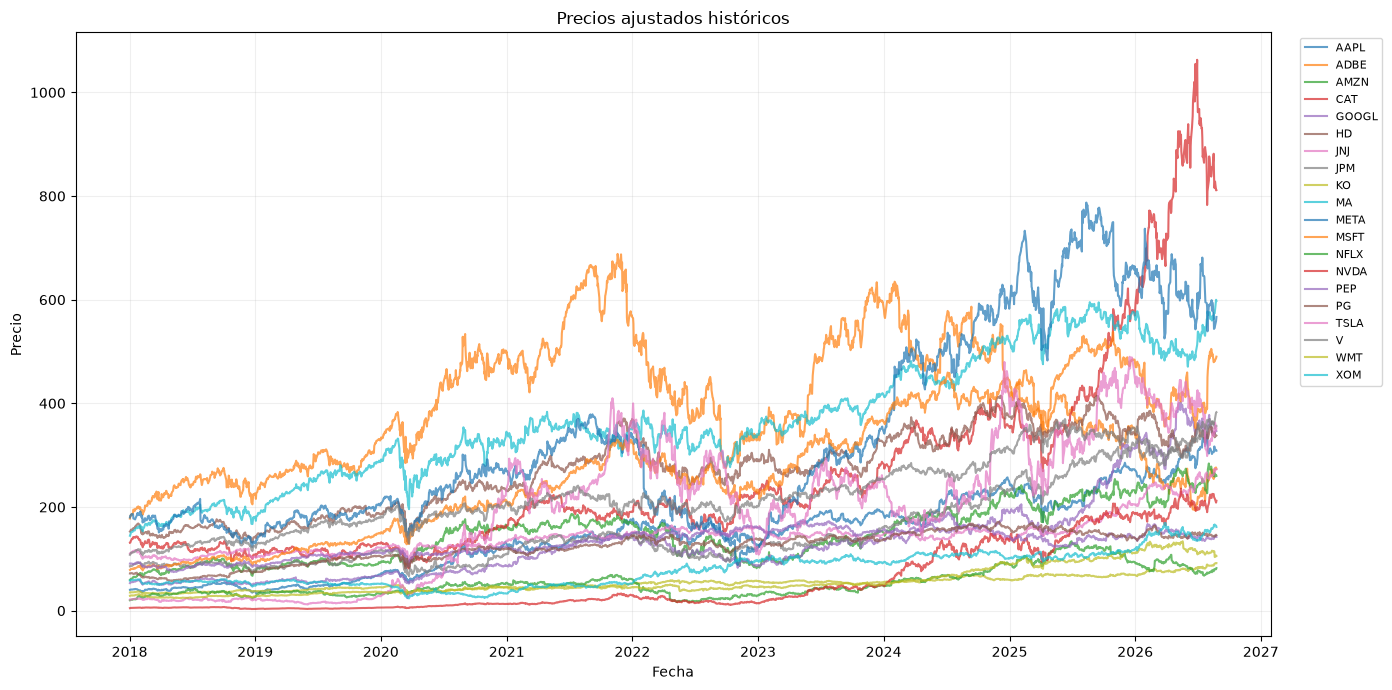

In [20]:
plt.figure(figsize=(14, 7))

for ticker in prices.columns:
    if ticker != "^GSPC":
        plt.plot(
            prices.index,
            prices[ticker],
            label=ticker,
            alpha=0.7
        )

plt.title("Precios ajustados históricos")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "01_precios_historicos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Rendimiento acumulado

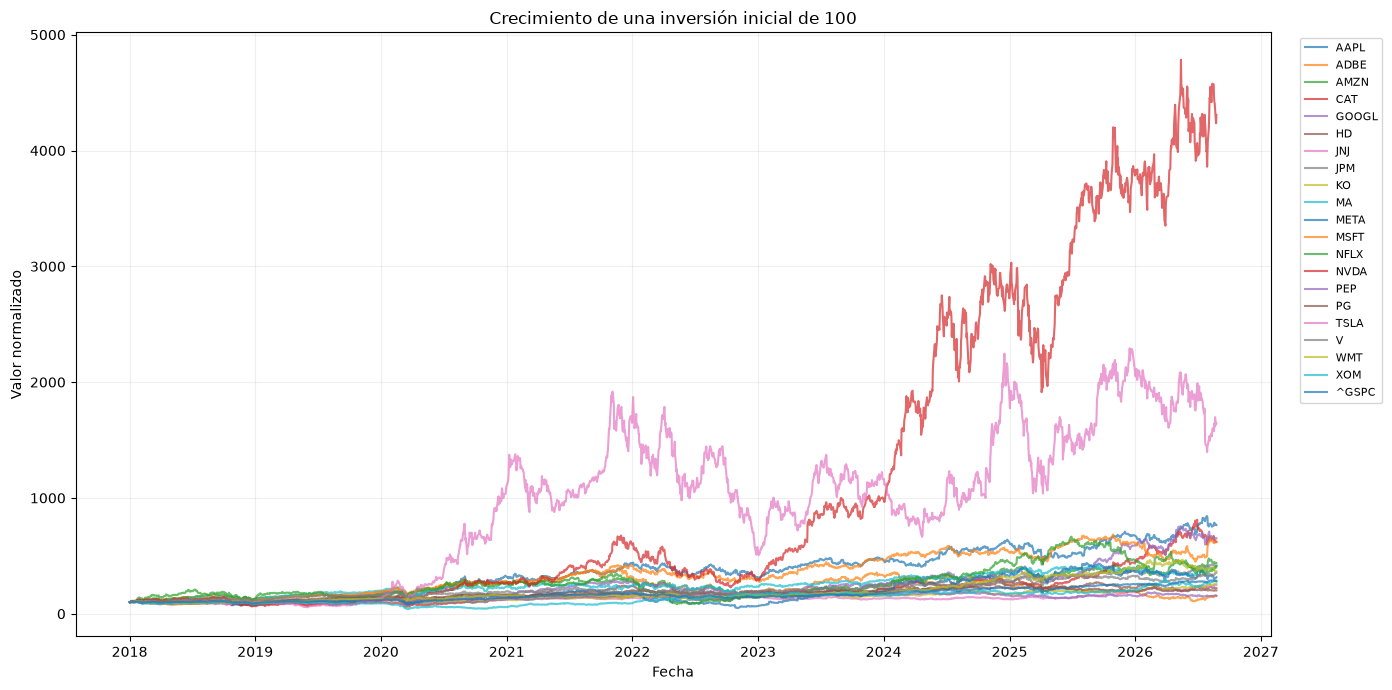

In [21]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 7))

for ticker in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=ticker,
        alpha=0.7
    )

plt.title("Crecimiento de una inversión inicial de 100")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "02_rendimiento_acumulado.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Comparación

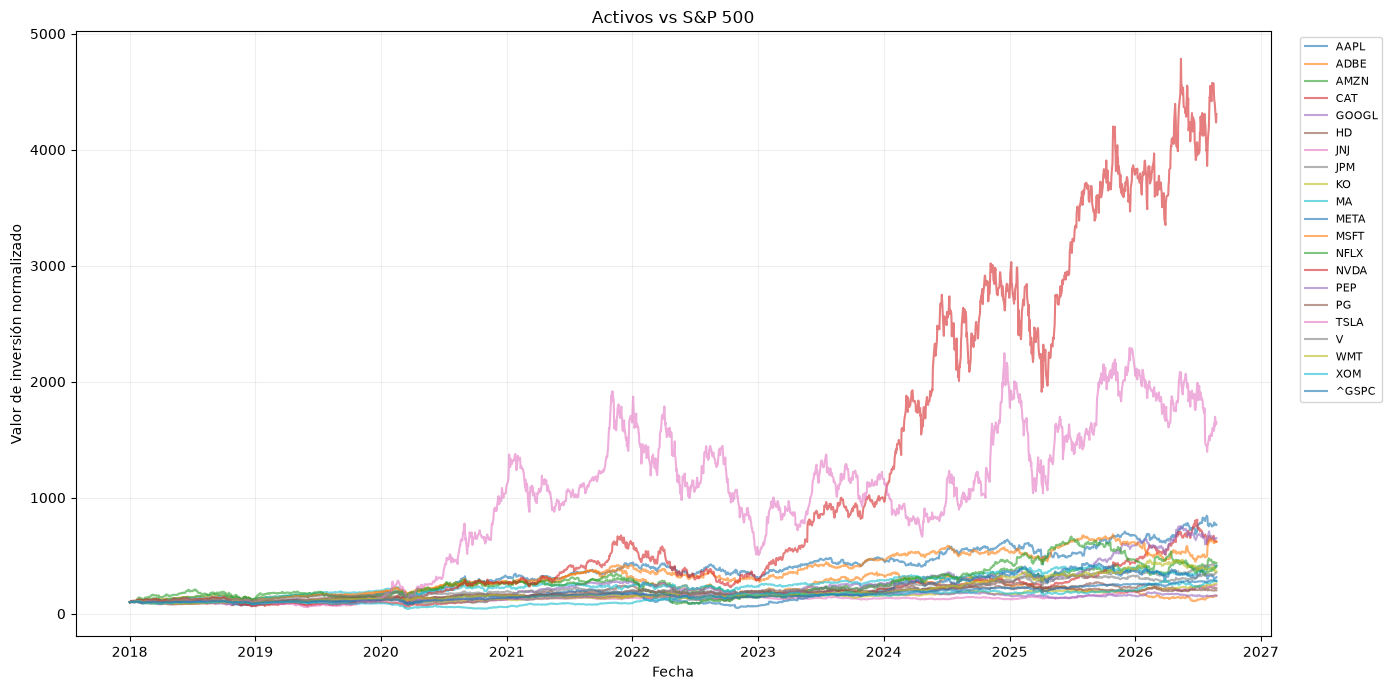

In [24]:
benchmark = "^GSPC"

asset_prices = prices.drop(columns=[benchmark])
asset_returns = returns.drop(columns=[benchmark])

sp500_prices = prices[benchmark]
sp500_returns = returns[benchmark]

comparison = pd.concat(
    [
        asset_prices / asset_prices.iloc[0] * 100,
        sp500_prices / sp500_prices.iloc[0] * 100
    ],
    axis=1
)

plt.figure(figsize=(14, 7))

for ticker in comparison.columns:
    plt.plot(
        comparison.index,
        comparison[ticker],
        label=ticker,
        alpha=0.6
    )

plt.title("Activos vs S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Valor de inversión normalizado")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "03_vs_sp500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Dist retornos

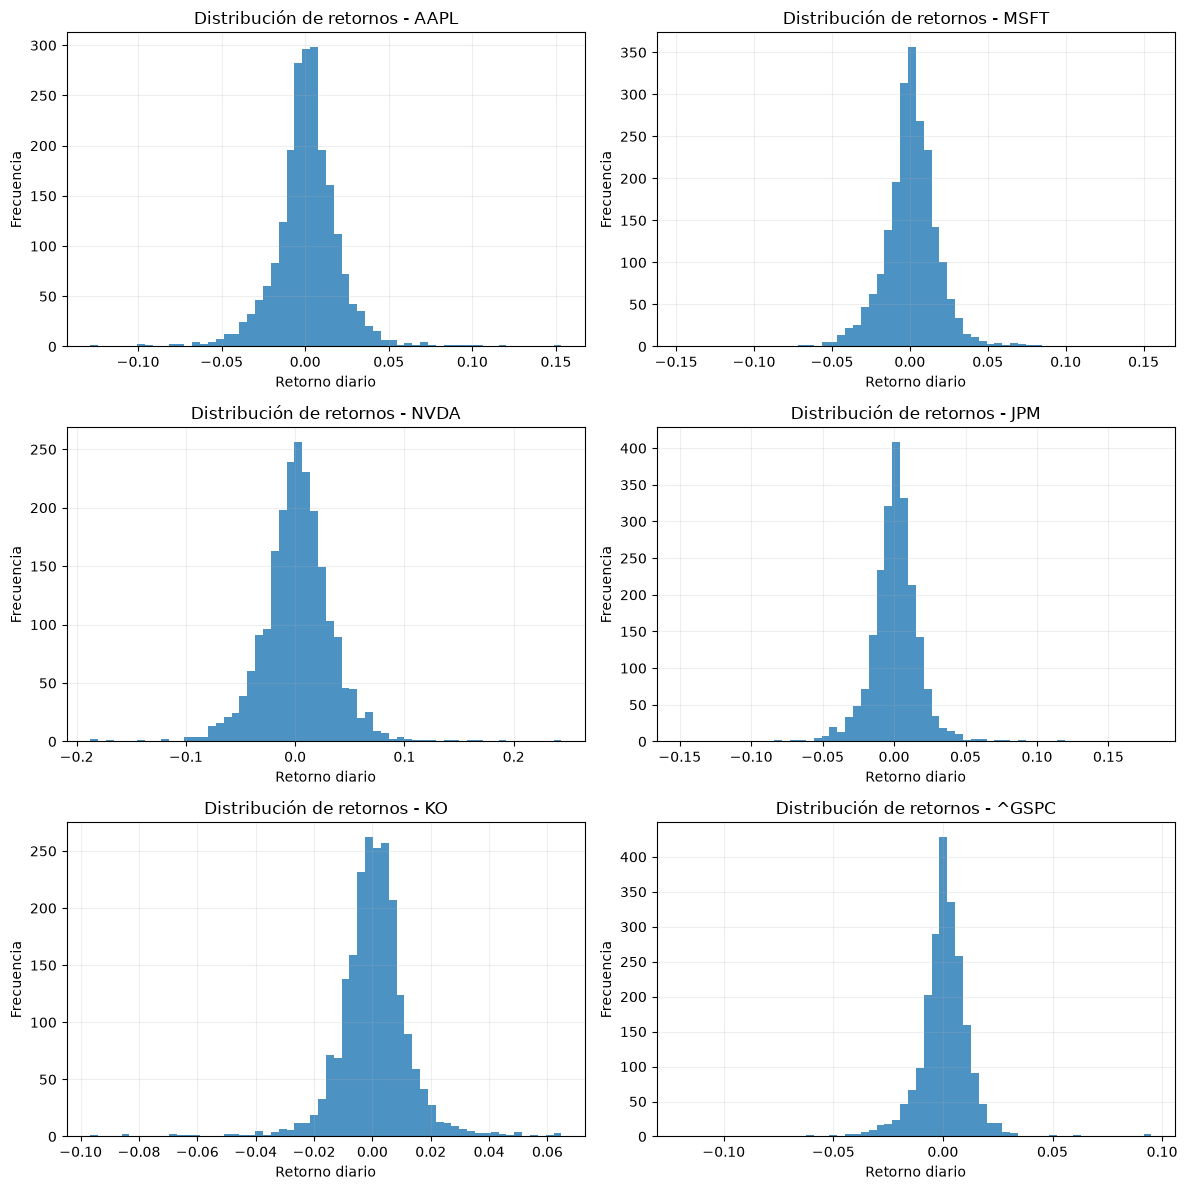

In [25]:
selected_assets = [
    "AAPL",
    "MSFT",
    "NVDA",
    "JPM",
    "KO",
    "^GSPC"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 12)
)

for ax, ticker in zip(axes.flatten(), selected_assets):

    ax.hist(
        returns[ticker].dropna(),
        bins=60,
        alpha=0.8
    )

    ax.set_title(f"Distribución de retornos - {ticker}")
    ax.set_xlabel("Retorno diario")
    ax.set_ylabel("Frecuencia")
    ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "04_distribuciones_retornos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Volatilidad

In [26]:
rolling_volatility = returns.rolling(
    window=30
).std() * np.sqrt(252)

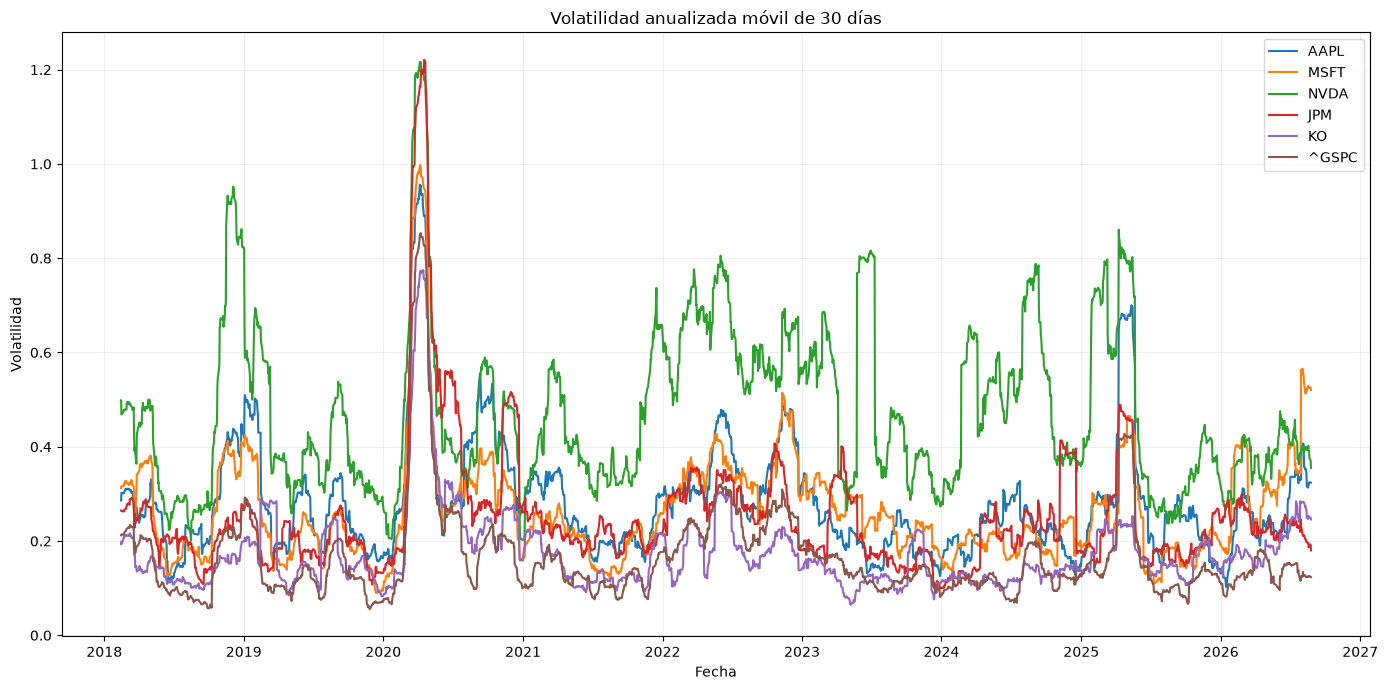

In [27]:
plt.figure(figsize=(14, 7))

for ticker in [
    "AAPL",
    "MSFT",
    "NVDA",
    "JPM",
    "KO",
    "^GSPC"
]:

    plt.plot(
        rolling_volatility.index,
        rolling_volatility[ticker],
        label=ticker
    )

plt.title("Volatilidad anualizada móvil de 30 días")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "05_volatilidad_movil.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Matriz de correlación

In [28]:
correlation_matrix = returns.corr()

correlation_matrix.round(2)

,AAPL,ADBE,AMZN,CAT,GOOGL,HD,JNJ,JPM,KO,MA,...,MSFT,NFLX,NVDA,PEP,PG,TSLA,V,WMT,XOM,^GSPC
AAPL,1.00,0.56,0.56,0.37,0.58,0.50,0.30,0.42,0.34,0.57,...,0.64,0.43,0.55,0.40,0.35,0.44,0.56,0.33,0.28,0.75
ADBE,0.56,1.00,0.56,0.22,0.55,0.46,0.22,0.31,0.27,0.55,...,0.67,0.48,0.52,0.32,0.26,0.35,0.55,0.26,0.18,0.63
AMZN,0.56,0.56,1.00,0.31,0.64,0.42,0.14,0.31,0.15,0.46,...,0.65,0.52,0.56,0.19,0.18,0.42,0.44,0.26,0.14,0.66
CAT,0.37,0.22,0.31,1.00,0.38,0.42,0.26,0.59,0.27,0.43,...,0.32,0.18,0.38,0.22,0.20,0.26,0.43,0.22,0.48,0.64
GOOGL,0.58,0.55,0.64,0.38,1.00,0.43,0.23,0.40,0.26,0.51,...,0.65,0.43,0.55,0.27,0.25,0.40,0.51,0.25,0.23,0.72
HD,0.50,0.46,0.42,0.42,0.43,1.00,0.37,0.48,0.43,0.52,...,0.49,0.30,0.41,0.49,0.44,0.31,0.53,0.40,0.29,0.69
JNJ,0.30,0.22,0.14,0.26,0.23,0.37,1.00,0.34,0.52,0.36,...,0.26,0.13,0.10,0.54,0.53,0.06,0.39,0.35,0.28,0.43
JPM,0.42,0.31,0.31,0.59,0.40,0.48,0.34,1.00,0.41,0.57,...,0.41,0.22,0.35,0.33,0.30,0.29,0.58,0.25,0.51,0.70
KO,0.34,0.27,0.15,0.27,0.26,0.43,0.52,0.41,1.00,0.48,...,0.31,0.13,0.13,0.71,0.62,0.11,0.47,0.37,0.36,0.50
MA,0.57,0.55,0.46,0.43,0.51,0.52,0.36,0.57,0.48,1.00,...,0.60,0.36,0.45,0.41,0.39,0.32,0.90,0.29,0.41,0.74


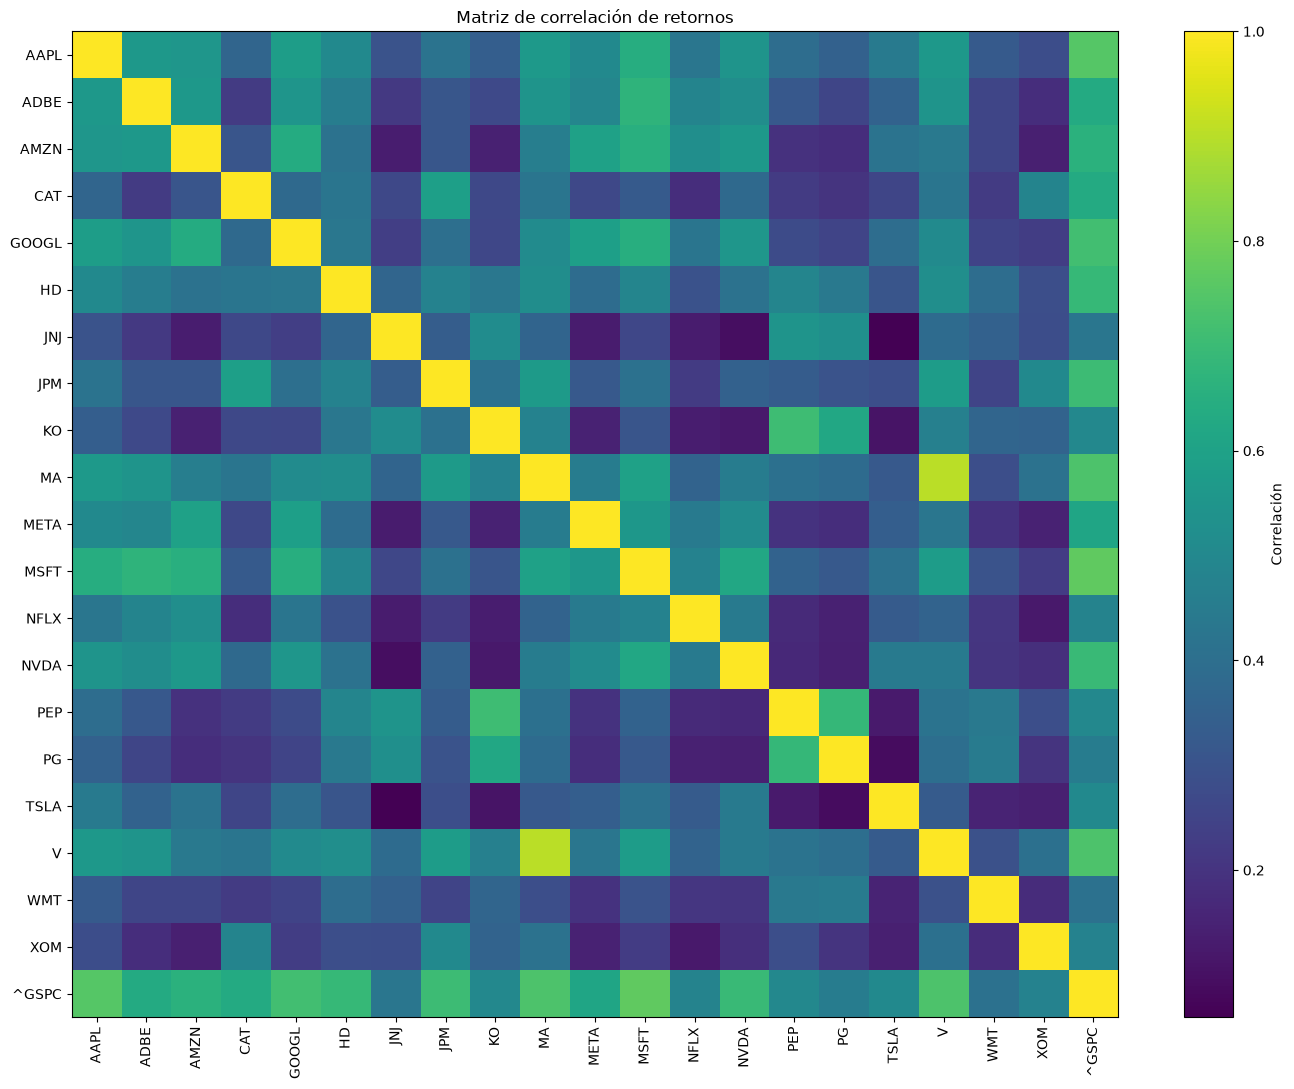

In [29]:
fig, ax = plt.subplots(figsize=(14, 11))

im = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    correlation_matrix.columns
)

ax.set_title("Matriz de correlación de retornos")

plt.colorbar(im, ax=ax, label="Correlación")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "06_matriz_correlacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

MA     V        0.902456
MSFT   ^GSPC    0.771194
AAPL   ^GSPC    0.752509
MA     ^GSPC    0.738610
V      ^GSPC    0.736257
GOOGL  ^GSPC    0.716643
KO     PEP      0.708750
JPM    ^GSPC    0.704383
NVDA   ^GSPC    0.695320
HD     ^GSPC    0.690741
dtype: float64

In [31]:
corr_pairs.tail(10)

^GSPC  MSFT    NaN
       NFLX    NaN
       NVDA    NaN
       PEP     NaN
       PG      NaN
       TSLA    NaN
       V       NaN
       WMT     NaN
       XOM     NaN
       ^GSPC   NaN
dtype: float64

Sharpe

In [32]:
annualized_return = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)

sharpe = (
    annualized_return /
    annualized_volatility
)

sharpe = sharpe.sort_values(
    ascending=False
)

sharpe

NVDA     1.118389
AAPL     0.926852
MSFT     0.874046
GOOGL    0.854017
TSLA     0.831100
CAT      0.809956
WMT      0.778475
^GSPC    0.727859
MA       0.721846
JPM      0.721415
V        0.700648
KO       0.673925
AMZN     0.668080
JNJ      0.634527
NFLX     0.601082
XOM      0.547152
META     0.530542
PG       0.508374
HD       0.482698
PEP      0.354436
ADBE     0.321132
dtype: float64

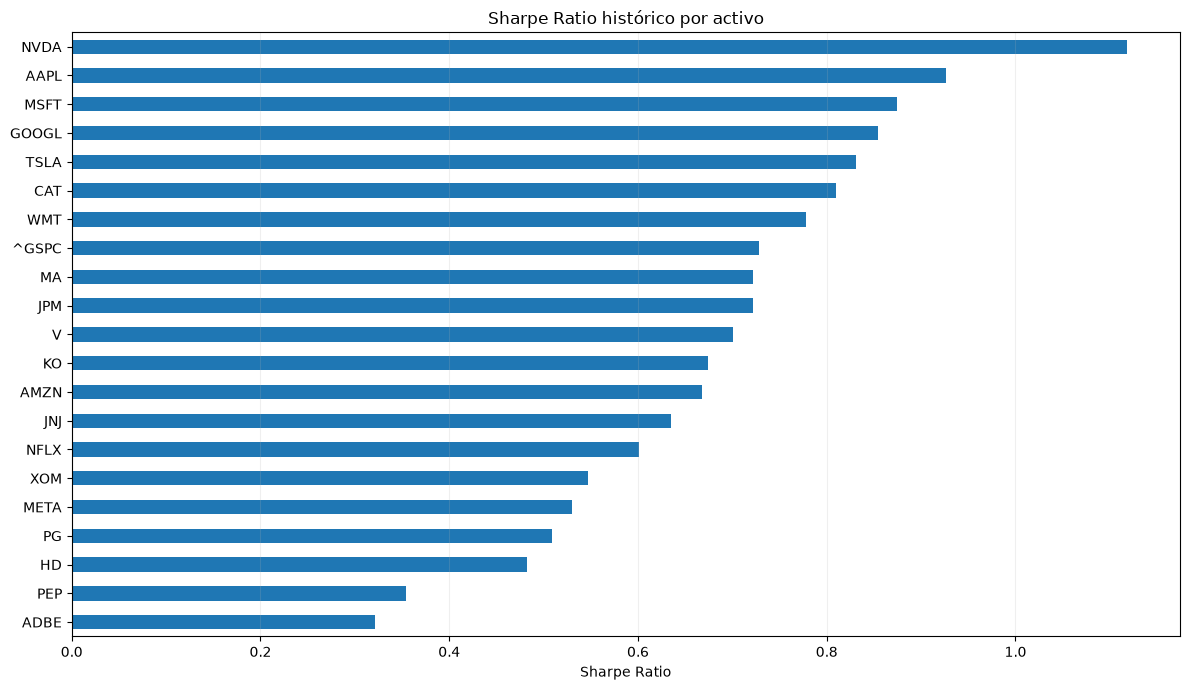

In [33]:
plt.figure(figsize=(12, 7))

sharpe.sort_values().plot(
    kind="barh"
)

plt.title("Sharpe Ratio histórico por activo")
plt.xlabel("Sharpe Ratio")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "07_sharpe_individual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Estacionalidad mensual

In [35]:
monthly_returns = (
    returns
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
)

monthly_seasonality = monthly_returns.groupby(
    monthly_returns.index.month
).mean()

monthly_seasonality

,AAPL,ADBE,AMZN,CAT,GOOGL,HD,JNJ,JPM,KO,MA,...,MSFT,NFLX,NVDA,PEP,PG,TSLA,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
1,0.002787,0.011260,0.078058,0.026403,0.056254,0.030830,0.019671,0.024745,0.009799,0.042536,...,0.016180,0.079752,0.071151,-0.000210,0.002388,0.079211,0.027893,0.025889,0.063218,0.019905
2,-0.009549,-0.039410,-0.027893,0.017345,-0.041092,-0.038030,-0.001392,0.005025,-0.000541,0.009883,...,-0.009478,0.030405,0.077287,-0.011931,-0.010975,-0.028648,0.012926,-0.017797,0.022415,-0.010656
3,-0.002160,-0.014445,0.016042,0.011188,-0.002705,-0.016797,0.008824,-0.046083,0.001033,-0.019180,...,0.011902,-0.002853,0.042294,0.015000,0.006601,-0.072299,-0.015581,0.015386,0.012921,-0.010919
4,0.024888,0.005296,0.061004,0.005359,0.066649,0.023628,0.000301,0.025350,0.026397,0.036494,...,0.042638,-0.027049,-0.000372,0.010365,0.014978,0.029947,0.039858,0.039492,0.023489,0.022553
5,0.029422,0.047430,0.014479,0.009715,0.037773,0.001732,-0.011294,0.017987,-0.003914,0.008956,...,0.047147,0.046292,0.122876,-0.020340,-0.018479,0.016347,0.010987,-0.021814,-0.009748,0.018906
6,0.047202,0.041532,0.035277,0.036189,-0.001435,0.036222,0.017680,0.006193,0.009457,0.002877,...,0.027071,0.034366,0.069909,0.009901,0.018126,0.106288,0.010700,0.011033,0.009307,0.018757
7,0.074398,0.052916,0.068452,0.021748,0.063128,0.034878,0.030222,0.051584,0.038035,0.049929,...,0.054001,-0.013393,0.059172,0.035017,0.025154,0.057237,0.025352,0.025858,0.015963,0.031217
8,0.057938,0.035247,0.008869,-0.007405,0.015780,0.027519,0.021909,0.003794,0.012759,0.031051,...,0.017815,0.051933,0.054631,0.010712,0.021953,0.087354,0.024826,0.038002,-0.002434,0.012993
9,-0.025151,-0.080374,-0.044187,0.026814,-0.020874,0.002480,-0.007928,-0.008162,-0.023786,-0.030078,...,-0.024876,-0.015935,-0.030957,-0.020925,-0.015891,0.043277,-0.039478,0.004673,-0.002340,-0.018990


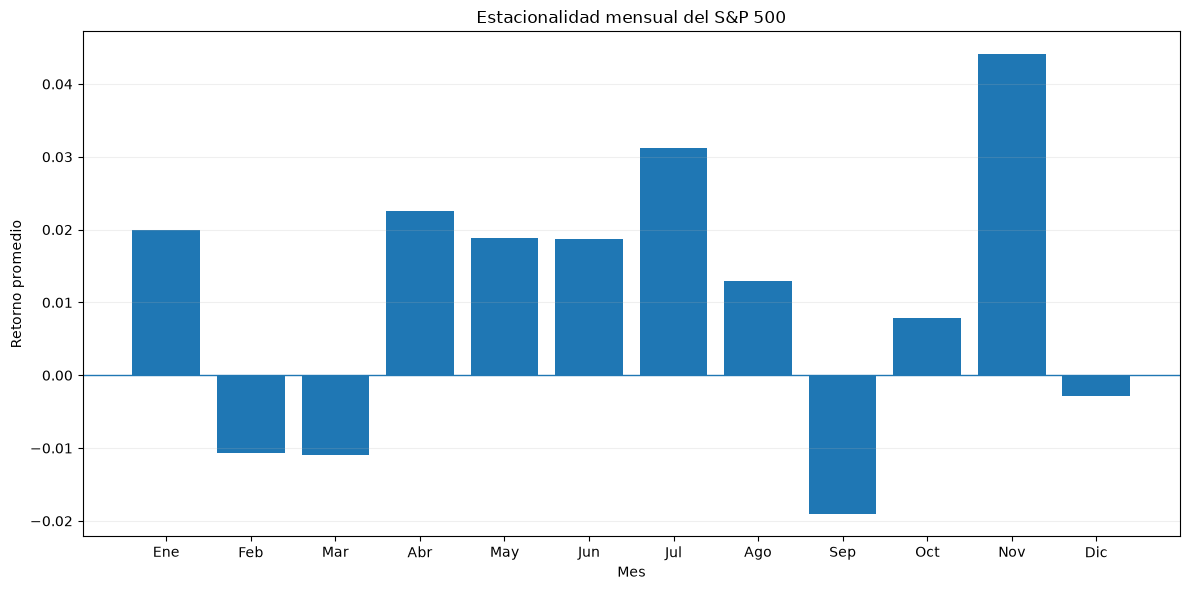

In [36]:
sp500_monthly = monthly_returns[benchmark]

monthly_avg = sp500_monthly.groupby(
    sp500_monthly.index.month
).mean()

months = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

plt.figure(figsize=(12, 6))

plt.bar(
    months,
    monthly_avg.values
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Estacionalidad mensual del S&P 500")
plt.xlabel("Mes")
plt.ylabel("Retorno promedio")

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "08_estacionalidad_sp500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
summary = pd.DataFrame({
    "Annual Return": annualized_return,
    "Annual Volatility": annualized_volatility,
    "Sharpe": sharpe,
    "Cumulative Return": (
        prices.iloc[-1] /
        prices.iloc[0]
    ) - 1
})

summary = summary.sort_values(
    "Sharpe",
    ascending=False
)

summary.round(4)

,Annual Return,Annual Volatility,Sharpe,Cumulative Return
NVDA,0.5638,0.5041,1.1184,42.0735
AAPL,0.2831,0.3054,0.9269,6.6717
MSFT,0.2549,0.2916,0.8740,5.2394
GOOGL,0.2661,0.3116,0.8540,5.5186
TSLA,0.5199,0.6255,0.8311,15.4622
CAT,0.2653,0.3276,0.8100,5.1924
WMT,0.1769,0.2272,0.7785,2.6742
^GSPC,0.1398,0.1921,0.7279,1.8449
MA,0.2049,0.2838,0.7218,3.1334
JPM,0.2066,0.2864,0.7214,3.1697


In [38]:
summary.to_csv(
    RESULTS_DIR / "eda_summary.csv"
)